In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
Germline = "HaPMAP_overlapping_germline_full.txt"

In [3]:
Reference = "HaPMAP_overlapping_reference_full.txt"

In [4]:
Somatic = "HaPMAP_somatic_candidates_full.txt"

In [5]:
PALMER_Calls = "HapMapmerged_numts_calls.txt"

In [6]:
def plotting(file, title, Bool):
    calls_df = pd.read_csv(file, sep='\t', header=None)

    calls_df.columns = [
        'chr', 'start1', 'end1', 'chr_p', 'start1_p', 'end1_p',"start1_inVariant","end1_inVariant",
        'cluster_id', 'Potential_supporting_reads', 'polyA_tail_TSD'
    ]
    if Bool == False:
        max_reads = calls_df['Potential_supporting_reads'].max()
    else:
        max_reads = 50

    plt.hist(
        calls_df['Potential_supporting_reads'],
        range=(2, max_reads),
        bins=100,
        histtype='bar',
        log=True
    )

    plt.xlabel('Number of Supporting Reads')
    plt.ylabel('Frequency')
    plt.title(f'{title}')
    plt.tight_layout()
    plt.show()


In [7]:
"""
“The NUMTs within a distance of 1,000 bp on both nuclear DNA and mtDNA were grouped as the same NUMT.” - Wei et al

Two calls might be:
- close in nuclear space
- AND similar in mtDNA fragment length → representing the same biological NUMT

Our Window is 25 bp for the nuclear position and 200 window for mitocodrial pobecause PALMER sometimes produces denser 
clusters than the short-read pipeline Wei used.
"""

def wei_style_dedup(input_file, output_file,
                            nuc_window=25, mt_window=200):

    cols = ['chr', 'start1', 'end1', 'chr_p', 'start1_p', 'end1_p',
            'start1_inVariant', 'end1_inVariant', 'cluster_id',
            'Potential_supporting_reads', 'polyA_tail_TSD']

    df = pd.read_csv(input_file, sep='\t', names=cols)
    df = df.sort_values(['chr_p', 'start1_p', 'start1_inVariant'])

    def intervals_overlap(a_start, a_end, b_start, b_end, window):
        return (a_start <= b_end + window) and (b_start <= a_end + window)

    groups = []
    current_group = [df.iloc[0]]

    for i in range(1, len(df)):
        prev = current_group[-1]
        curr = df.iloc[i]

        same_chr = prev['chr'] == curr['chr']

        nuc_overlap = intervals_overlap(prev['start1'], prev['end1'],
                                        curr['start1'], curr['end1'],
                                        nuc_window)

        mt_overlap = intervals_overlap(prev['start1_inVariant'], prev['end1_inVariant'],
                                       curr['start1_inVariant'], curr['end1_inVariant'],
                                       mt_window)

        if same_chr and nuc_overlap and mt_overlap:
            current_group.append(curr)
        else:
            groups.append(current_group)
            current_group = [curr]

    groups.append(current_group)

    # representative = highest‐supporting call
    dedup_rows = [
        max(g, key=lambda r: r['Potential_supporting_reads'])
        for g in groups
    ]

    out = pd.DataFrame(dedup_rows)
    out.to_csv(output_file, sep='\t', index=False, header=False)

    print(f"Original: {len(df)}, Deduped: {len(out)}, Removed: {len(df) - len(out)}")

In [8]:
#wei_style_dedup('STmerged_numts_calls.txt', 'Tissue_numts_calls_dedup.txt')
#output:
#Original: 543738, Deduped: 500827, Removed: 42911
#after 
#495174

In [9]:
# Run for each category
wei_style_dedup('HaPMAP_somatic_candidates_full.txt', 'somatic_candidates_full_dedup.txt')
wei_style_dedup('HaPMAP_overlapping_germline_full.txt', 'overlapping_germline_full_dedup.txt')
wei_style_dedup('HaPMAP_overlapping_reference_full.txt', 'overlapping_reference_full_dedup.txt')

Original: 105440, Deduped: 87689, Removed: 17751
Original: 146, Deduped: 33, Removed: 113
Original: 785, Deduped: 243, Removed: 542


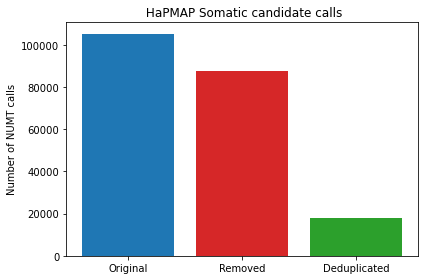

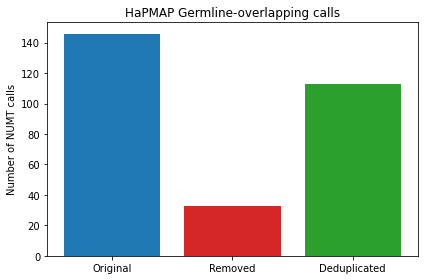

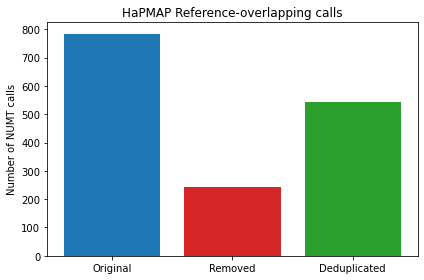

In [1]:
import matplotlib.pyplot as plt

datasets = {
    " HaPMAP Somatic candidate calls": {
        "Original": 105440,
        "Removed": 87689,
        "Deduplicated": 17751
    },
    "HaPMAP Germline-overlapping calls": {
        "Original": 146,
        "Removed": 33,
        "Deduplicated": 113
    },
    "HaPMAP Reference-overlapping calls": {
        "Original": 785,
        "Removed": 243,
        "Deduplicated": 542
    }
}

colors = {
    "Original": "#1f77b4",       # blue
    "Deduplicated": "#2ca02c",   # green
    "Removed": "#d62728"         # red
}

for title, values in datasets.items():
    labels = list(values.keys())
    counts = list(values.values())
    bar_colors = [colors[label] for label in labels]

    plt.figure()
    plt.bar(labels, counts, color=bar_colors)
    plt.ylabel("Number of NUMT calls")
    plt.title(title)
    plt.tight_layout()
    plt.show()


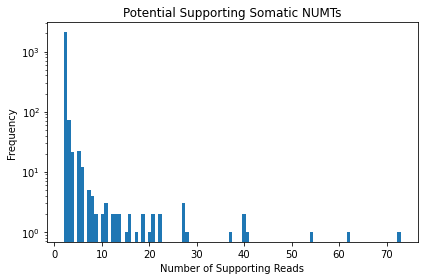

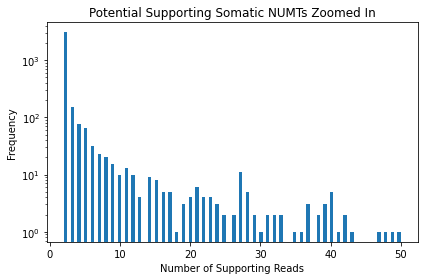

In [11]:
plotting('somatic_candidates_full_dedup.txt', "Potential Supporting Somatic NUMTs",False)
plotting(Somatic, "Potential Supporting Somatic NUMTs Zoomed In",True)

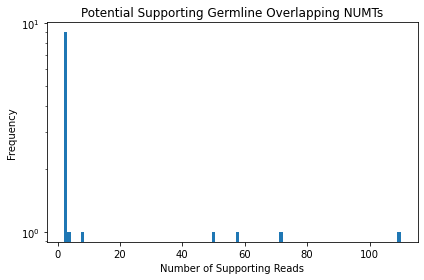

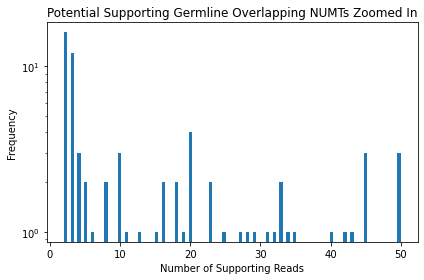

In [12]:
plotting('overlapping_germline_full_dedup.txt', "Potential Supporting Germline Overlapping NUMTs",False)
plotting(Germline, "Potential Supporting Germline Overlapping NUMTs Zoomed In",True)

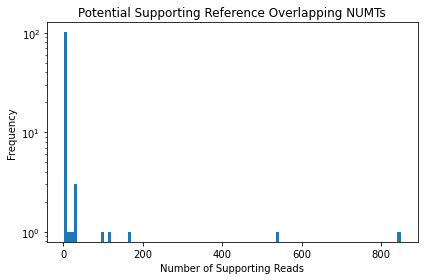

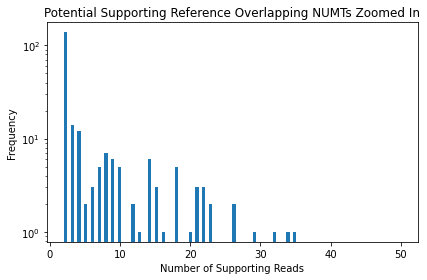

In [13]:
plotting('overlapping_reference_full_dedup.txt', "Potential Supporting Reference Overlapping NUMTs",False)
plotting(Reference, "Potential Supporting Reference Overlapping NUMTs Zoomed In",True)

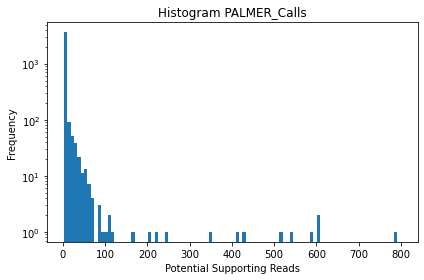

In [14]:
    calls_df =pd.read_csv(PALMER_Calls, sep='\t')
    plt.hist(
        calls_df['Potential_supporting_reads'],

        range=(2,800),  
        histtype='bar',
        bins = 100,
        log= True
        )

    plt.xlabel('Potential Supporting Reads')
    plt.ylabel('Frequency')
    plt.title('Histogram PALMER_Calls')
    plt.tight_layout()
    plt.show()
    

In [15]:
import pandas as pd

def deduplicate_numts(input_file, output_file):
    # Column names based on your specification
    cols = ['chr', 'start1', 'end1', 'chr_p', 'start1_p', 'end1_p',
            'start1_inVariant', 'end1_inVariant', 'cluster_id', 
            'Potential_supporting_reads', 'polyA_tail_TSD']
    
    df = pd.read_csv(input_file, sep='\t', names=cols)
    
    # Group by chr_p and 10bp windows of start1_p
    df['group'] = df.groupby('chr_p')['start1_p'].transform(
        lambda x: (x // 10) * 10  # Create 10bp bins
    )
    
    # Within each group, keep the row with max Potential_supporting_reads
    idx = df.groupby(['chr_p', 'group'])['Potential_supporting_reads'].idxmax()
    df_dedup = df.loc[idx].drop('group', axis=1)
    
    # Sort by genomic position
    df_dedup = df_dedup.sort_values(['chr_p', 'start1_p'])
    
    # Save
    df_dedup.to_csv(output_file, sep='\t', index=False, header=False)
    
    print(f"Original: {len(df)} entries")
    print(f"Deduplicated: {len(df_dedup)} entries")
    print(f"Removed: {len(df) - len(df_dedup)} redundant entries")

# Run for each category
deduplicate_numts('HaPMAP_somatic_candidates_full.txt', 'somatic_candidates_full_dedup.txt')
deduplicate_numts('HaPMAP_overlapping_germline_full.txt', 'overlapping_germline_full_dedup.txt')
deduplicate_numts('HaPMAP_overlapping_reference_full.txt', 'overlapping_reference_full_dedup.txt')

Original: 105440 entries
Deduplicated: 80250 entries
Removed: 25190 redundant entries
Original: 146 entries
Deduplicated: 37 entries
Removed: 109 redundant entries
Original: 785 entries
Deduplicated: 238 entries
Removed: 547 redundant entries
